# Graph Metrics Table & Trace
- **7,7 conditioned:** 10 simulation runs → mean ± std trace (shadow)
- **Random / FF:** 10 random seeds at t=TIME_FINAL → mean ± std errorbar at endpoint
- Binary threshold: weight ≥ 1
- Metrics: Global Clustering Coeff · Global Efficiency · Modularity · Assortativity

In [2]:
# ─────────────────────────────────────────────
# ★ 여기만 수정하세요
# ─────────────────────────────────────────────
BASE_DIR         = "/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/"

# 7,7 시뮬레이션 run 목록 (폴더명 기준, 10개)
# 실제 폴더 구조에 맞게 수정하세요
RUN_LABELS = ["7_7"] + [f"7_7({i})" for i in range(1, 10)]  # ← 실제 폴더명으로 수정
DT1, DT2         = 7, 7

TIME_FINAL       = 3600

BINARY_THRESHOLD = 1.0
MATRIX_SIZE      = 800
FF_WEIGHT_UPPER  = 4.0
FF_WEIGHT_LOWER  = 0.0
FF_BASE_SEED     = 42       # Random & FF: seed 42~51 (10개)

FF_GROUPS        = [
    list(range(0,   50)),
    list(range(375, 425)),
    list(range(750, 800)),
]

# trace용 시간 포인트
TRACE_TIMES = list(range(0, 3601, 100))   # 100s ~ 3600s, 매 100s
N_RUNS      = 10
# ─────────────────────────────────────────────

In [85]:
import os
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams['figure.dpi']     = 100
plt.rcParams['font.family']    = 'sans-serif'
plt.rcParams['axes.linewidth'] = 1.5
print("Libraries loaded.")

Libraries loaded.


## 1. 그래프 생성 함수

In [86]:
def load_graph(base_dir, label, dt1, dt2, time, matrix_size):
    record_path = os.path.join(base_dir, f"data_{label}", "record")
    prefix = f"{dt1},{dt2}ms interval, weight in {int(time)}s"
    g   = np.load(os.path.join(record_path, prefix + "_data.npy"))
    row = np.load(os.path.join(record_path, prefix + "_row.npy"))
    col = np.load(os.path.join(record_path, prefix + "_col.npy"))
    G = nx.DiGraph()
    G.add_nodes_from(range(matrix_size))
    for i in range(len(g)):
        G.add_edge(int(row[i]), int(col[i]), weight=float(g[i]))
    return G


def make_binary_graph(G, threshold):
    G2 = nx.DiGraph()
    G2.add_nodes_from(G.nodes())
    for u, v, d in G.edges(data=True):
        if d['weight'] >= threshold:
            G2.add_edge(u, v, weight=1.0)
    return G2


def make_random_graph(n, n_edges, seed=0):
    rng = np.random.default_rng(seed)
    G = nx.DiGraph()
    G.add_nodes_from(range(n))
    possible = [(i, j) for i in range(n) for j in range(n) if i != j]
    chosen = rng.choice(len(possible), size=n_edges, replace=False)
    for idx in chosen:
        i, j = possible[idx]
        G.add_edge(i, j, weight=1.0)
    return G


def make_ff_graph(n, n_edges, seed=0):
    rng = np.random.default_rng(seed)
    upper = [(i, j) for i in range(n) for j in range(i+1, n)]
    chosen = rng.choice(len(upper), size=n_edges, replace=False)
    G = nx.DiGraph()
    G.add_nodes_from(range(n))
    for idx in chosen:
        i, j = upper[idx]
        G.add_edge(i, j, weight=1.0)
    return G


def directed_global_efficiency(G):
    n = G.number_of_nodes()
    if n < 2:
        return 0.0
    s = 0.0
    for u in G.nodes():
        lengths = nx.single_source_shortest_path_length(G, u)
        for v, d in lengths.items():
            if v != u and d > 0:
                s += 1.0 / d
    return s / (n * (n - 1))

## 2. 메트릭 계산 함수

In [87]:



def compute_metrics(G):
    gcc  = nx.average_clustering(G)
    ge   = directed_global_efficiency(G)
    comm = nx.community.louvain_communities(G, seed=42)
    mod  = nx.community.modularity(G, comm)
    try:
        assort_out_in  = nx.degree_assortativity_coefficient(G, x='out', y='in')
        assort_in_in   = nx.degree_assortativity_coefficient(G, x='in',  y='in')
        assort_out_out = nx.degree_assortativity_coefficient(G, x='out', y='out')
        assort_in_out  = nx.degree_assortativity_coefficient(G, x='in',  y='out')
    except Exception:
        assort_out_in = assort_in_in = assort_out_out = assort_in_out = float('nan')
    return {
        'gcc':           gcc,
        'efficiency':    ge,
        'modularity':    mod,
        'assort_out_in':  assort_out_in,
        'assort_in_in':   assort_in_in,
        'assort_out_out': assort_out_out,
        'assort_in_out':  assort_in_out,
    }

METRICS = [
    ('gcc',           'Global Clustering Coeff.'),
    ('efficiency',    'Global Efficiency'),
    ('modularity',    'Modularity Q'),
    ('assort_out_in',  'Assortativity (out→in)'),
    ('assort_in_in',   'Assortativity (in→in)'),
    ('assort_out_out', 'Assortativity (out→out)'),
    ('assort_in_out',  'Assortativity (in→out)'),
]

print("Metric functions defined.")

Metric functions defined.


## 3. 7,7 Conditioned — 10 runs × Trace 계산

In [88]:
# shape: (N_RUNS, len(TRACE_TIMES))
run_traces = {mkey: np.full((N_RUNS, len(TRACE_TIMES)), np.nan) for mkey, _ in METRICS}
edge_counts_start = []
edge_counts_end   = []
for run_idx, run_label in enumerate(RUN_LABELS):
    print(f"\n[Run {run_idx+1}/{N_RUNS}]  label={run_label}")
    for t_idx, t in enumerate(TRACE_TIMES):
        G_raw = load_graph(BASE_DIR, run_label, DT1, DT2, t, MATRIX_SIZE)
        G_bin = make_binary_graph(G_raw, BINARY_THRESHOLD)
        m = compute_metrics(G_bin)
        for mkey, _ in METRICS:
            run_traces[mkey][run_idx, t_idx] = m[mkey]
        if t == TRACE_TIMES[0]:
            edge_counts_start.append(G_bin.number_of_edges())
        if t == TIME_FINAL:
            edge_counts_end.append(G_bin.number_of_edges())

        if t % 300 == 0 or t == TRACE_TIMES[-1]:
            print(f"  t={t:4d}s  edges={G_bin.number_of_edges()}  "
                  f"GCC={m['gcc']:.4f}  Eff={m['efficiency']:.4f}  "
                    f"Mod={m['modularity']:.4f}  "
                    f"Assort(out-in)={m['assort_out_in']:.4f}  "
                    f"Assort(in-in)={m['assort_in_in']:.4f}  "
                    f"Assort(out-out)={m['assort_out_out']:.4f}  "
                    f"Assort(in-out)={m['assort_in_out']:.4f}")

trace_mean = {mkey: np.nanmean(run_traces[mkey], axis=0) for mkey, _ in METRICS}
trace_std  = {mkey: np.nanstd (run_traces[mkey], axis=0) for mkey, _ in METRICS}

# 끝점 edge 수: run별 평균 사용 (Random/FF edge 수 기준)
n_edges_start = int(np.mean(edge_counts_start))
n_edges_end   = int(np.mean(edge_counts_end))
print(f"\n✓ Trace done.")
print(f"  Edge count start (t={TRACE_TIMES[0]}s): {n_edges_start}  {edge_counts_start}")
print(f"  Edge count end   (t={TIME_FINAL}s):     {n_edges_end}    {edge_counts_end}")


[Run 1/10]  label=7_7
  t=   0s  edges=64051  GCC=0.1002  Eff=0.5500  Mod=0.0634  Assort(out-in)=0.0017  Assort(in-in)=-0.0068  Assort(out-out)=-0.0040  Assort(in-out)=-0.0036
  t= 300s  edges=18364  GCC=0.0288  Eff=0.4075  Mod=0.1276  Assort(out-in)=-0.1458  Assort(in-in)=0.0853  Assort(out-out)=0.0634  Assort(in-out)=-0.0156
  t= 600s  edges=17427  GCC=0.0279  Eff=0.3988  Mod=0.1264  Assort(out-in)=-0.1994  Assort(in-in)=0.1012  Assort(out-out)=0.0721  Assort(in-out)=0.0035
  t= 900s  edges=18267  GCC=0.0292  Eff=0.4091  Mod=0.1267  Assort(out-in)=-0.1617  Assort(in-in)=0.0718  Assort(out-out)=0.0400  Assort(in-out)=0.0190
  t=1200s  edges=17753  GCC=0.0281  Eff=0.4040  Mod=0.1274  Assort(out-in)=-0.1861  Assort(in-in)=0.0887  Assort(out-out)=0.0452  Assort(in-out)=0.0288
  t=1500s  edges=17448  GCC=0.0283  Eff=0.3994  Mod=0.1289  Assort(out-in)=-0.1695  Assort(in-in)=0.0797  Assort(out-out)=0.0370  Assort(in-out)=0.0315
  t=1800s  edges=17850  GCC=0.0288  Eff=0.4004  Mod=0.1245  As

## 4. Random / FF — 10 seeds at t=TIME_FINAL

In [89]:
rand_vals_start = {mkey: [] for mkey, _ in METRICS}
ff_vals_start   = {mkey: [] for mkey, _ in METRICS}
rand_vals_end   = {mkey: [] for mkey, _ in METRICS}
ff_vals_end     = {mkey: [] for mkey, _ in METRICS}

for i in range(N_RUNS):
    seed = FF_BASE_SEED + i

    G_rand = make_random_graph(MATRIX_SIZE, n_edges_start, seed=seed)
    m = compute_metrics(G_rand)
    for mkey, _ in METRICS: rand_vals_start[mkey].append(m[mkey])

    G_ff = make_ff_graph(MATRIX_SIZE, n_edges_start, seed=seed)
    m = compute_metrics(G_ff)
    for mkey, _ in METRICS: ff_vals_start[mkey].append(m[mkey])

    G_rand = make_random_graph(MATRIX_SIZE, n_edges_end, seed=seed)
    m = compute_metrics(G_rand)
    for mkey, _ in METRICS: rand_vals_end[mkey].append(m[mkey])

    G_ff = make_ff_graph(MATRIX_SIZE, n_edges_end,   seed=seed)
    m = compute_metrics(G_ff)
    for mkey, _ in METRICS: ff_vals_end[mkey].append(m[mkey])

    print(f"  seed={seed}  done")

rand_mean_start, rand_std_start = {mkey: np.mean(v) for mkey,v in rand_vals_start.items()}, {mkey: np.std(v) for mkey,v in rand_vals_start.items()}
ff_mean_start,   ff_std_start   = {mkey: np.mean(v) for mkey,v in ff_vals_start.items()},   {mkey: np.std(v) for mkey,v in ff_vals_start.items()}
rand_mean_end,   rand_std_end   = {mkey: np.mean(v) for mkey,v in rand_vals_end.items()},   {mkey: np.std(v) for mkey,v in rand_vals_end.items()}
ff_mean_end,     ff_std_end     = {mkey: np.mean(v) for mkey,v in ff_vals_end.items()},     {mkey: np.std(v) for mkey,v in ff_vals_end.items()}

  seed=42  done
  seed=43  done
  seed=44  done
  seed=45  done
  seed=46  done
  seed=47  done
  seed=48  done
  seed=49  done
  seed=50  done
  seed=51  done


## 5. Trace + Endpoint 시각화

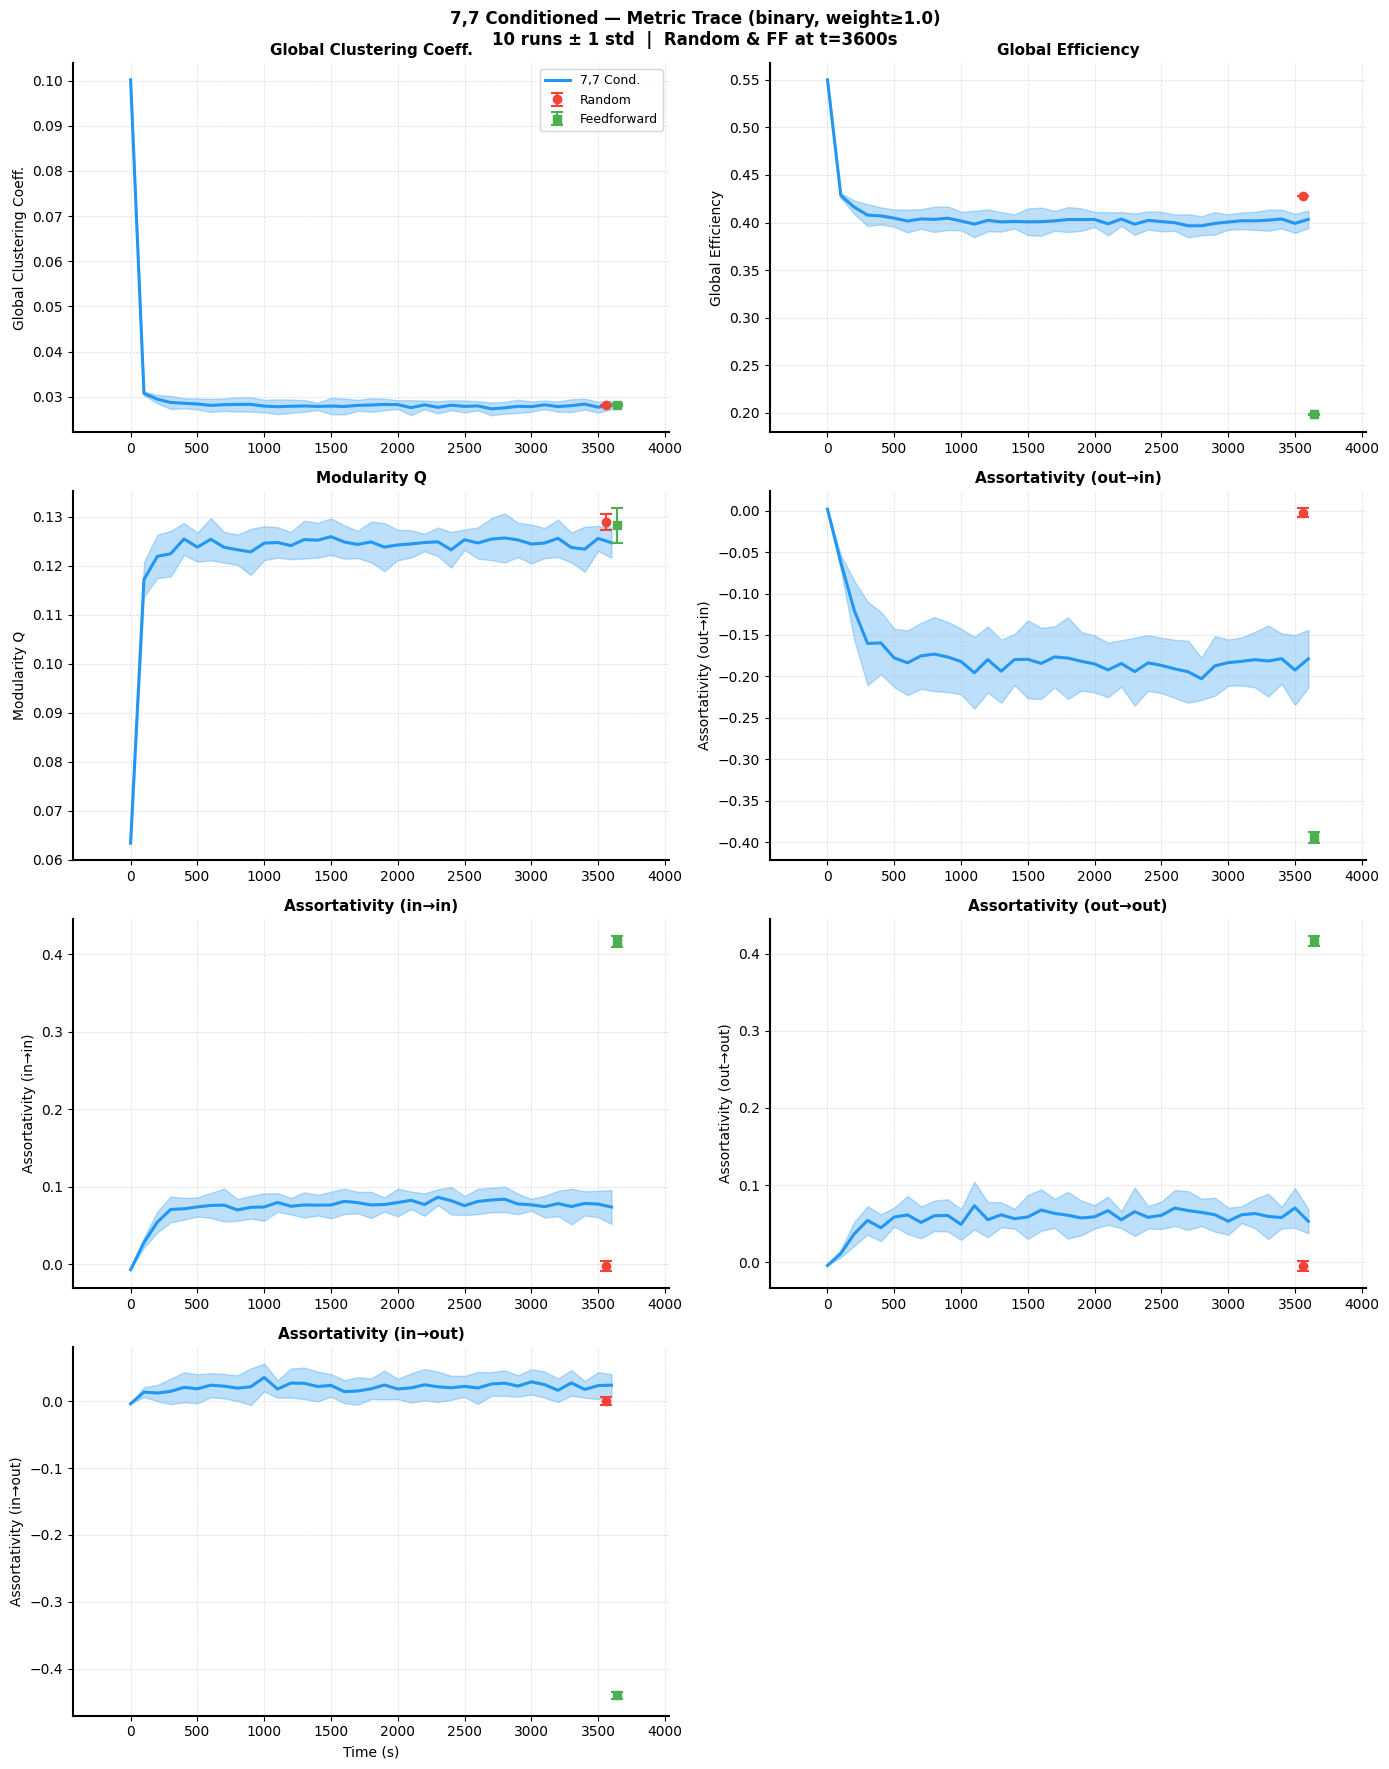

✓ Figure saved -> /media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/metrics_trace_v4.svg


In [92]:
COLOR_77   = '#2196F3'   # blue  — 7,7 conditioned
COLOR_RAND = '#F44336'   # red   — random
COLOR_FF   = '#4CAF50'   # green — feedforward

t_arr   = np.array(TRACE_TIMES)
T_END   = TIME_FINAL
# 추가
T_START = TRACE_TIMES[0]
JITTER  = (T_END - T_START) * 0.012

fig, axes = plt.subplots(4, 2, figsize=(14, 18))


fig.suptitle(
    f'7,7 Conditioned — Metric Trace (binary, weight≥{BINARY_THRESHOLD})\n'
    f'{N_RUNS} runs ± 1 std  |  Random & FF at t={T_END}s',
    fontsize=12, fontweight='bold'
)

for ax_idx, (mkey, mlabel) in enumerate(METRICS):
    ax   = axes[ax_idx // 2, ax_idx % 2]
    mean = trace_mean[mkey]
    std  = trace_std[mkey]

    # ── 7,7 trace: shadow + line
    ax.fill_between(t_arr, mean - std, mean + std,
                    color=COLOR_77, alpha=0.3, zorder=1)
    ax.plot(t_arr, mean,
            color=COLOR_77, linewidth=2.2, zorder=2, label='7,7 Cond.')

    # ── Random errorbar (끝점 왼쪽)
    #ax.errorbar(T_START - JITTER, rand_mean_start[mkey], yerr=rand_std_start[mkey],
    #        fmt='o', color=COLOR_RAND, markersize=8, capsize=4, capthick=1.5, linewidth=1.5, zorder=4)
    #ax.errorbar(T_START + JITTER, ff_mean_start[mkey],   yerr=ff_std_start[mkey],
    #        fmt='s', color=COLOR_FF,   markersize=8, capsize=4, capthick=1.5, linewidth=1.5, zorder=4)
    ax.errorbar(T_END   - JITTER, rand_mean_end[mkey],   yerr=rand_std_end[mkey],
            fmt='o', color=COLOR_RAND, markersize=6, capsize=4, capthick=1.5, linewidth=1.5, zorder=4, label='Random')
    ax.errorbar(T_END   + JITTER, ff_mean_end[mkey],     yerr=ff_std_end[mkey],
            fmt='s', color=COLOR_FF,   markersize=6, capsize=4, capthick=1.5, linewidth=1.5, zorder=4, label='Feedforward')


    ax.set_ylabel(mlabel, fontsize=10)
    ax.set_title(mlabel, fontsize=11, fontweight='bold')
    ax.set_xlim(T_START - JITTER * 10, T_END + JITTER * 10)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.45)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    if ax_idx == 0:
        ax.legend(fontsize=9, loc='best')

for ax in axes[3]:
    ax.set_xlabel('Time (s)', fontsize=10)
axes[3, 1].set_visible(False)
plt.tight_layout()
save_path = os.path.join(BASE_DIR, 'metrics_trace_v4.svg')
plt.savefig(save_path, format='svg', transparent=True, bbox_inches='tight')
plt.show()
print(f"✓ Figure saved -> {save_path}")

## 6. Summary Table 시각화 (끝점 mean ± std)

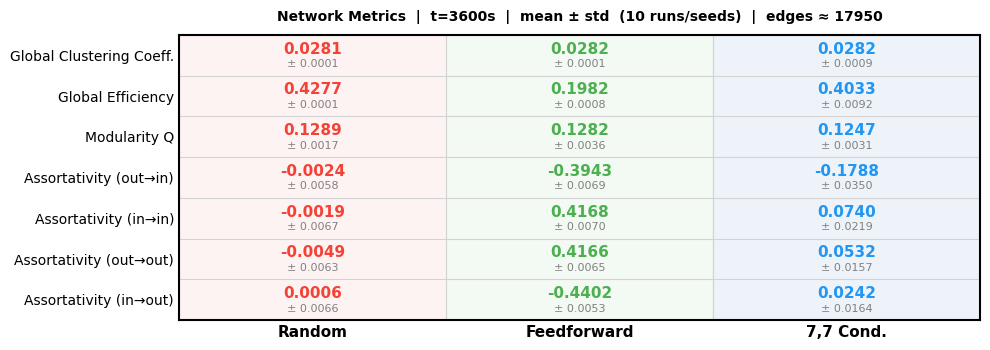

✓ Summary table saved -> /media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/data/Triplet_Raster/metrics_table_v4.svg


In [93]:
# 7,7 끝점 (t=TIME_FINAL, 즉 trace 마지막 time point)
cond_mean_ep = {mkey: trace_mean[mkey][-1] for mkey, _ in METRICS}
cond_std_ep  = {mkey: trace_std[mkey][-1]  for mkey, _ in METRICS}

NET_NAMES  = ['Random', 'Feedforward', '7,7 Cond.']
means_list = [rand_mean_end, ff_mean_end, cond_mean_ep]
stds_list  = [rand_std_end,  ff_std_end,  cond_std_ep]

fig, ax = plt.subplots(figsize=(10, 3.6))
ax.set_facecolor('white')
ax.set_xlim(-0.5, len(NET_NAMES) - 0.5)
ax.set_ylim(-0.5, len(METRICS) - 0.5)
ax.invert_yaxis()

# 헤더 컬럼 색
header_colors = ['#fde9e9', '#e9f5e9', '#dce9f5']
for c_idx, hc in enumerate(header_colors):
    ax.add_patch(plt.Rectangle((c_idx - 0.5, -0.5), 1, len(METRICS),
                                color=hc, alpha=0.5, zorder=0))

for x in np.arange(-0.5, len(NET_NAMES), 1):
    ax.axvline(x, color='lightgray', linewidth=0.8)
for y in np.arange(-0.5, len(METRICS), 1):
    ax.axhline(y, color='lightgray', linewidth=0.8)

NET_COLORS = [COLOR_RAND, COLOR_FF, COLOR_77]
for r_idx, (mkey, mlabel) in enumerate(METRICS):
    for c_idx, (name, means, stds, nc) in enumerate(
            zip(NET_NAMES, means_list, stds_list, NET_COLORS)):
        mu  = means[mkey]
        sig = stds[mkey]
        ax.text(c_idx, r_idx - 0.15, f'{mu:.4f}',
                ha='center', va='center', fontsize=11, fontweight='bold', color=nc)
        ax.text(c_idx, r_idx + 0.22, f'± {sig:.4f}',
                ha='center', va='center', fontsize=8, color='gray')

ax.set_xticks(range(len(NET_NAMES)))
ax.set_xticklabels(NET_NAMES, fontsize=11, fontweight='bold')
ax.set_yticks(range(len(METRICS)))
ax.set_yticklabels([m[1] for m in METRICS], fontsize=10)
ax.tick_params(length=0)
ax.set_title(
    f'Network Metrics  |  t={T_END}s  |  mean ± std  ({N_RUNS} runs/seeds)'
    f'  |  edges ≈ {n_edges_end}',
    fontsize=10, fontweight='bold', pad=10
)

plt.tight_layout()
save_path = os.path.join(BASE_DIR, 'metrics_table_v4.svg')
plt.savefig(save_path, format='svg', transparent=True, bbox_inches='tight')
plt.show()
print(f"✓ Summary table saved -> {save_path}")

## 7. 수치 저장 (CSV)

In [ ]:
# Summary table CSV
rows = []
for name, means, stds in zip(NET_NAMES, means_list, stds_list):
    row = {'network': name}
    for mkey, mlabel in METRICS:
        row[mlabel + '_mean'] = means[mkey]
        row[mlabel + '_std']  = stds[mkey]
    rows.append(row)
df_table = pd.DataFrame(rows).set_index('network')
print(df_table.round(6).to_string())
df_table.to_csv(os.path.join(BASE_DIR, 'metrics_table_v4.csv'))

# Trace CSV
df_trace = pd.DataFrame({'time': TRACE_TIMES})
for mkey, mlabel in METRICS:
    df_trace[mlabel + '_mean'] = trace_mean[mkey]
    df_trace[mlabel + '_std']  = trace_std[mkey]
df_trace.to_csv(os.path.join(BASE_DIR, 'metrics_trace_v4.csv'), index=False)

print("\n✓ CSVs saved.")

In [53]:
record_path = os.path.join(BASE_DIR, "data_7_7", "record")
files = sorted([f for f in os.listdir(record_path) if '_data.npy' in f])
for f in files:
    print(f)

7,7ms interval, weight in 0s_data.npy
7,7ms interval, weight in 10000s_data.npy
7,7ms interval, weight in 1000s_data.npy
7,7ms interval, weight in 10010s_data.npy
7,7ms interval, weight in 10020s_data.npy
7,7ms interval, weight in 10030s_data.npy
7,7ms interval, weight in 10040s_data.npy
7,7ms interval, weight in 10050s_data.npy
7,7ms interval, weight in 10060s_data.npy
7,7ms interval, weight in 10070s_data.npy
7,7ms interval, weight in 10080s_data.npy
7,7ms interval, weight in 10090s_data.npy
7,7ms interval, weight in 100s_data.npy
7,7ms interval, weight in 10100s_data.npy
7,7ms interval, weight in 1010s_data.npy
7,7ms interval, weight in 10110s_data.npy
7,7ms interval, weight in 10120s_data.npy
7,7ms interval, weight in 10130s_data.npy
7,7ms interval, weight in 10140s_data.npy
7,7ms interval, weight in 10150s_data.npy
7,7ms interval, weight in 10160s_data.npy
7,7ms interval, weight in 10170s_data.npy
7,7ms interval, weight in 10180s_data.npy
7,7ms interval, weight in 10190s_data.npy


In [3]:
import matplotlib
matplotlib.rcParams.update(matplotlib.rcParamsDefault)
plt.rcParams['axes.labelsize']      = 45.72
plt.rcParams['xtick.labelsize']     = 30
plt.rcParams['ytick.labelsize']     = 30
plt.rcParams['axes.linewidth']      = 2.0
plt.rcParams['figure.dpi']          = 100
plt.rcParams['font.family']         = 'sans-serif'
plt.rcParams['font.sans-serif']     = ['Arial']
plt.rcParams['font.weight']         = 'bold'
plt.rcParams['xtick.major.width']   = 2.5
plt.rcParams['ytick.major.width']   = 2.5
plt.rcParams['xtick.major.size']    = 8
plt.rcParams['ytick.major.size']    = 8
plt.rcParams['svg.fonttype']        = 'none'
BASE_DIR = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/figure260518 supp'
fig, ax = plt.subplots(figsize=(10.5, 7.5))
mkey, mlabel = 'efficiency', 'Global efficiency'

ax.fill_between(t_arr, trace_mean[mkey] - trace_std[mkey],
                        trace_mean[mkey] + trace_std[mkey],
                color=COLOR_77, alpha=0.3, zorder=1)
ax.plot(t_arr, trace_mean[mkey], color=COLOR_77, linewidth=3, zorder=2, label='7,7 Cond.')
ax.errorbar(T_END , rand_mean_end[mkey], yerr=rand_std_end[mkey],
            fmt='o', color=COLOR_RAND, markersize=8, capsize=5, capthick=2, linewidth=2, zorder=4, label='Random')
ax.errorbar(T_END, ff_mean_end[mkey], yerr=ff_std_end[mkey],
            fmt='s', color=COLOR_FF, markersize=8, capsize=5, capthick=2, linewidth=2, zorder=4, label='Feedforward')

ax.set_xlabel('Time (s)')
ax.set_ylabel(mlabel)
ax.set_xlim(T_START - JITTER , T_END + JITTER )
ax.set_xticks([0, 1200, 2400, 3600])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=20, loc='lower left', bbox_to_anchor=(0.05, 0.05))

plt.tight_layout()
save_path = os.path.join(BASE_DIR, 'supp_efficiency_trace.svg')
plt.savefig(save_path, format='svg', transparent=True, bbox_inches='tight')
plt.show()
print(f"✓ Saved -> {save_path}")

NameError: name 'plt' is not defined

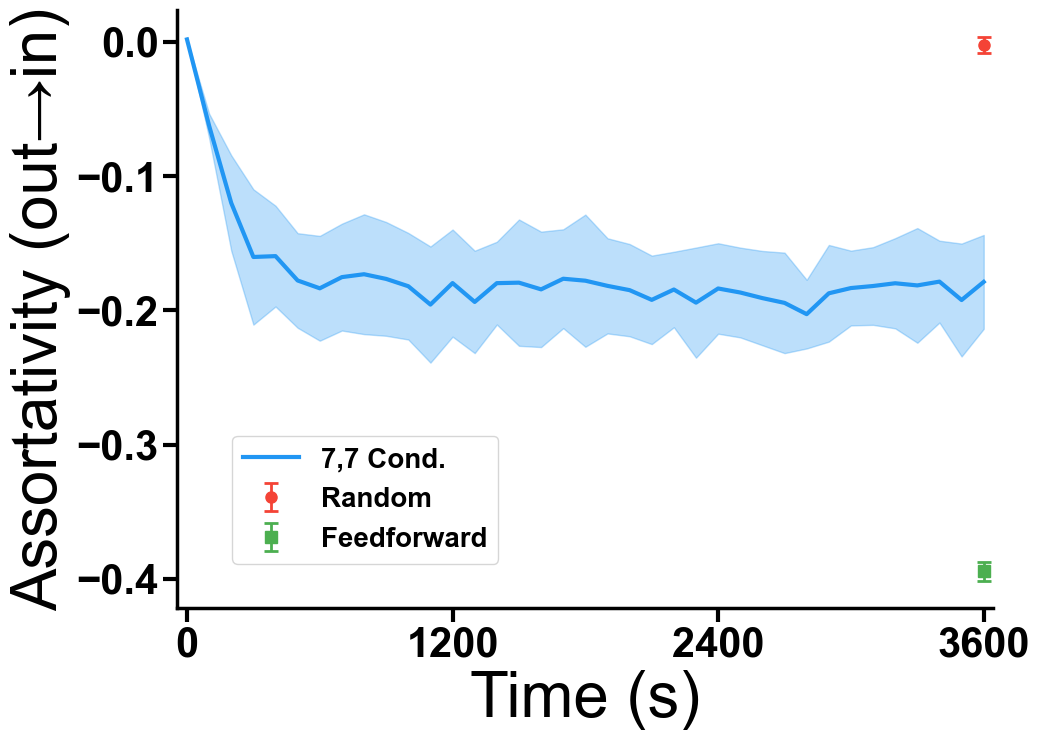

✓ Saved -> /media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/figure260518 supp/supp_Assortativity (out→in)_trace.svg


In [111]:
import matplotlib
matplotlib.rcParams.update(matplotlib.rcParamsDefault)
plt.rcParams['axes.labelsize']      = 45.72
plt.rcParams['xtick.labelsize']     = 30
plt.rcParams['ytick.labelsize']     = 30
plt.rcParams['axes.linewidth']      = 2.5
plt.rcParams['figure.dpi']          = 100
plt.rcParams['font.family']         = 'sans-serif'
plt.rcParams['font.sans-serif']     = ['Arial']
plt.rcParams['font.weight']         = 'bold'
plt.rcParams['xtick.major.width']   = 3
plt.rcParams['ytick.major.width']   = 3
plt.rcParams['xtick.major.size']    = 10
plt.rcParams['ytick.major.size']    = 10
plt.rcParams['svg.fonttype']        = 'none'
BASE_DIR = '/media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/figure260518 supp'
fig, ax = plt.subplots(figsize=(10.5, 7.5))
mkey, mlabel = 'assort_out_in', 'Assortativity (out→in)'

ax.fill_between(t_arr, trace_mean[mkey] - trace_std[mkey],
                        trace_mean[mkey] + trace_std[mkey],
                color=COLOR_77, alpha=0.3, zorder=1)
ax.plot(t_arr, trace_mean[mkey], color=COLOR_77, linewidth=3, zorder=2, label='7,7 Cond.')
ax.errorbar(T_END , rand_mean_end[mkey], yerr=rand_std_end[mkey],
            fmt='o', color=COLOR_RAND, markersize=8, capsize=5, capthick=2, linewidth=2, zorder=4, label='Random')
ax.errorbar(T_END, ff_mean_end[mkey], yerr=ff_std_end[mkey],
            fmt='s', color=COLOR_FF, markersize=8, capsize=5, capthick=2, linewidth=2, zorder=4, label='Feedforward')

ax.set_xlabel('Time (s)')
ax.set_ylabel(mlabel)
ax.set_xlim(T_START - JITTER , T_END + JITTER )

ax.set_xticks([0, 1200, 2400, 3600])
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(fontsize=20, loc='lower left', bbox_to_anchor=(0.05, 0.05))

plt.tight_layout()
save_path = os.path.join(BASE_DIR, 'supp_Assortativity (out→in)_trace.svg')
plt.savefig(save_path, format='svg', transparent=True, bbox_inches='tight')
plt.show()
print(f"✓ Saved -> {save_path}")

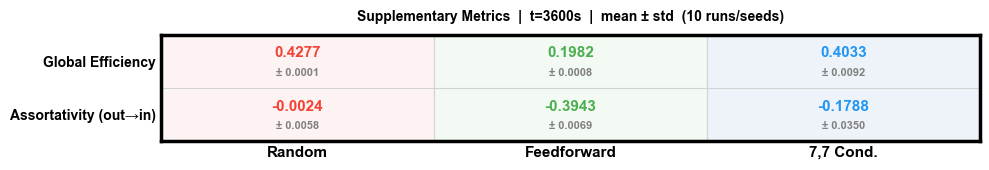

✓ Supplementary table saved -> /media/inhoi/12tbstorage/eprop_triplet_sdf_classifier/figure260518 supp/supp_assortativity_trace.svg


In [103]:
# ── Supplementary Table: Global Efficiency & Assortativity (out→in)
fig, ax = plt.subplots(figsize=(10, 1.8))
ax.set_facecolor('white')
ax.set_xlim(-0.5, len(NET_NAMES) - 0.5)
ax.set_ylim(-0.5, len(SUPP_METRICS) - 0.5)
ax.invert_yaxis()

for c_idx, hc in enumerate(['#fde9e9', '#e9f5e9', '#dce9f5']):
    ax.add_patch(plt.Rectangle((c_idx - 0.5, -0.5), 1, len(SUPP_METRICS),
                                color=hc, alpha=0.5, zorder=0))
for x in np.arange(-0.5, len(NET_NAMES), 1):
    ax.axvline(x, color='lightgray', linewidth=0.8)
for y in np.arange(-0.5, len(SUPP_METRICS), 1):
    ax.axhline(y, color='lightgray', linewidth=0.8)

for r_idx, (mkey, mlabel) in enumerate(SUPP_METRICS):
    for c_idx, (means, stds, nc) in enumerate(
            zip(means_list, stds_list, NET_COLORS)):
        ax.text(c_idx, r_idx - 0.15, f'{means[mkey]:.4f}',
                ha='center', va='center', fontsize=11, fontweight='bold', color=nc)
        ax.text(c_idx, r_idx + 0.22, f'± {stds[mkey]:.4f}',
                ha='center', va='center', fontsize=8, color='gray')

ax.set_xticks(range(len(NET_NAMES)))
ax.set_xticklabels(NET_NAMES, fontsize=11, fontweight='bold')
ax.set_yticks(range(len(SUPP_METRICS)))
ax.set_yticklabels([m[1] for m in SUPP_METRICS], fontsize=10)
ax.tick_params(length=0)
ax.set_title(
    f'Supplementary Metrics  |  t={T_END}s  |  mean ± std  ({N_RUNS} runs/seeds)',
    fontsize=10, fontweight='bold', pad=10
)

plt.tight_layout()
save_path = os.path.join(BASE_DIR, 'supp_assortativity_trace.svg')
plt.savefig(save_path, format='svg', transparent=True, bbox_inches='tight')
plt.show()
print(f"✓ Supplementary table saved -> {save_path}")